In [31]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# =========================
# 기본 경로 설정
# =========================
base_path = r"C:\Users\u\Desktop\CICIDS2017\CICIDS2017_improved"

# 파일 경로
file_attempted_separated = os.path.join(base_path, "merged.csv")                   # Attempted 분리 상태
file_attempted_origin = os.path.join(base_path, "merged_Attempted_origin.csv")     # Attempted -> 기존 공격 라벨
file_attempted_benign = os.path.join(base_path, "merged_Attempted_Begin.csv")      # Attempted -> BENIGN


In [33]:
# =========================
# 공통 전처리 함수
# =========================
def preprocess_dataset(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    print("=" * 100)
    print(f"[불러온 파일] {os.path.basename(csv_path)}")
    print("원본 shape:", df.shape)
    print("\n원본 라벨 분포:")
    print(df["Label"].value_counts())

    # 논문에서 shortcut learning 위험으로 지적한 컬럼 제거
    drop_cols = [
        "id",
        "Flow ID",
        "Src IP",
        "Src Port",
        "Dst IP",
        "Timestamp",
        "Attempted Category"
    ]
    drop_cols = [c for c in drop_cols if c in df.columns]
    df = df.drop(columns=drop_cols)

    print("\n불필요 컬럼 제거 후 shape:", df.shape)

    # inf / -inf 처리
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # 결측 제거
    before_dropna = df.shape[0]
    df.dropna(inplace=True)
    after_dropna = df.shape[0]

    print(f"\n결측 제거 전 행 수: {before_dropna}")
    print(f"결측 제거 후 행 수: {after_dropna}")
    print(f"제거된 행 수: {before_dropna - after_dropna}")

    X = df.drop(columns=["Label"])
    y = df["Label"]

    print("\n최종 X shape:", X.shape)
    print("최종 y shape:", y.shape)
    print("\n최종 라벨 분포:")
    print(y.value_counts())
    print("\n최종 feature 개수:", X.shape[1])

    return X, y


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
# =========================
# 학습 / 평가 함수
# =========================
def train_and_evaluate_rf(X, y, exp_name):
    print("\n" + "#" * 100)
    print(f"[실험 시작] {exp_name}")
    print("#" * 100)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.25,
        random_state=42,
        stratify=y
    )

    print("\n[데이터 분할 결과]")
    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test :", y_test.shape)

    rf = RandomForestClassifier(
        n_estimators=10,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    print("\n[Accuracy]")
    print(acc)

    print("\n[Weighted F1]")
    print(weighted_f1)

    print("\n[Classification Report]")
    print(classification_report(y_test, y_pred, digits=4))

    labels_sorted = sorted(y.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)
    cm_df = pd.DataFrame(cm, index=labels_sorted, columns=labels_sorted)

    print("\n[Confusion Matrix]")
    print(cm_df)

    report_dict = classification_report(y_test, y_pred, digits=4, output_dict=True)
    class_rows = []
    for label, metrics in report_dict.items():
        if label in ["accuracy", "macro avg", "weighted avg"]:
            continue
        class_rows.append({
            "label": label,
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1-score": metrics["f1-score"],
            "support": metrics["support"]
        })

    result_df = pd.DataFrame(class_rows).sort_values(by="f1-score", ascending=False)

    return {
        "experiment": exp_name,
        "model": rf,
        "accuracy": acc,
        "weighted_f1": weighted_f1,
        "class_report_df": result_df,
        "confusion_matrix_df": cm_df,
        "y_test": y_test,
        "y_pred": y_pred
    }


In [51]:
# =========================
# 실험 1: Attempted 분리 상태
# =========================
X_sep, y_sep = preprocess_dataset(file_attempted_separated)
result_sep = train_and_evaluate_rf(X_sep, y_sep, "Attempted 분리 상태")


# =========================
# 실험 2: Attempted -> 기존 공격 라벨
# =========================
X_org, y_org = preprocess_dataset(file_attempted_origin)
result_org = train_and_evaluate_rf(X_org, y_org, "Attempted -> 기존 공격 라벨")


# =========================
# 실험 3: Attempted -> BENIGN
# =========================
X_ben, y_ben = preprocess_dataset(file_attempted_benign)
result_ben = train_and_evaluate_rf(X_ben, y_ben, "Attempted -> BENIGN")


# =========================
# 최종 요약 비교
# =========================
print("\n" + "=" * 100)
print("[최종 요약 비교]")
print("=" * 100)

summary_df = pd.DataFrame([
    {
        "Experiment": result_sep["experiment"],
        "Accuracy": result_sep["accuracy"]
    },
    {
        "Experiment": result_org["experiment"],
        "Accuracy": result_org["accuracy"]
    },
    {
        "Experiment": result_ben["experiment"],
        "Accuracy": result_ben["accuracy"]
    }
])

print(summary_df)

[불러온 파일] merged.csv
원본 shape: (2099976, 91)

원본 라벨 분포:
Label
BENIGN                                    1582566
Portscan                                   159066
DoS Hulk                                   158468
DDoS                                        95144
Infiltration - Portscan                     71767
DoS GoldenEye                                7567
Botnet - Attempted                           4067
FTP-Patator                                  3972
DoS Slowloris                                3859
DoS Slowhttptest - Attempted                 3368
SSH-Patator                                  2961
DoS Slowloris - Attempted                    1847
DoS Slowhttptest                             1740
Web Attack - Brute Force - Attempted         1292
Botnet                                        736
Web Attack - XSS - Attempted                  655
DoS Hulk - Attempted                          581
DoS GoldenEye - Attempted                      80
Web Attack - Brute Force               

C:\Users\u\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\u\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\u\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                            precision    recall  f1-score   support

                    BENIGN     0.9999    1.0000    1.0000    398635
                    Botnet     1.0000    1.0000    1.0000       184
                      DDoS     1.0000    1.0000    1.0000     23786
             DoS GoldenEye     0.9995    0.9984    0.9989      1892
                  DoS Hulk     1.0000    0.9999    0.9999     39617
          DoS Slowhttptest     0.9885    0.9885    0.9885       435
             DoS Slowloris     1.0000    0.9979    0.9990       965
               FTP-Patator     1.0000    1.0000    1.0000       993
                Heartbleed     1.0000    1.0000    1.0000         3
              Infiltration     1.0000    0.7778    0.8750         9
   Infiltration - Portscan     0.9059    0.9152    0.9105     17942
                  Portscan     0.9616    0.9570    0.9593     39767
               SSH-Patator     1.0000    1.0000    1.0000       740
  Web Attack - Brute Force     1.0000    0.9444

C:\Users\u\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\u\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



[최종 요약 비교]
              Experiment  Accuracy
0        Attempted 분리 상태  0.993213
1  Attempted -> 기존 공격 라벨  0.993257
2    Attempted -> BENIGN  0.993794


C:\Users\u\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              Experiment  Accuracy  Weighted F1
0        Attempted 분리 상태  0.993213     0.993205
1  Attempted -> 기존 공격 라벨  0.993257     0.993249
2    Attempted -> BENIGN  0.993794     0.993799


C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:30: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:30: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:30: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:30: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:30: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:30: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  plt.ti

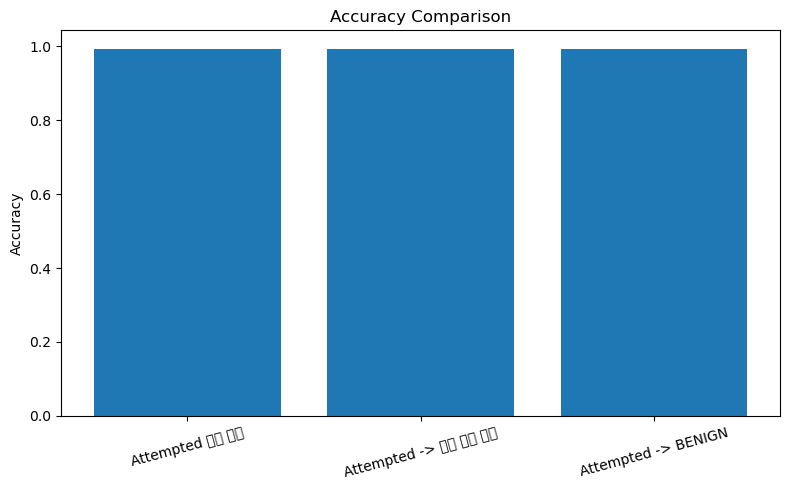

C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:39: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:39: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:39: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:39: UserWarning: Glyph 53468 (\N{HANGUL SYLLABLE TAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:39: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\u\AppData\Local\Temp\ipykernel_3172\3192199660.py:39: UserWarning: Glyph 51316 (\N{HANGUL SYLLABLE JON}) missing from font(s) DejaVu Sans.
  plt.ti

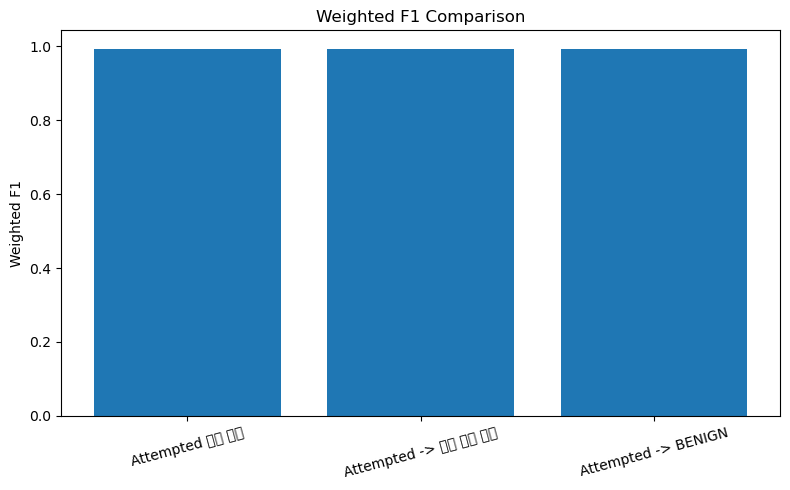

In [53]:
import matplotlib.pyplot as plt
import pandas as pd

summary_df = pd.DataFrame([
    {
        "Experiment": result_sep["experiment"],
        "Accuracy": result_sep["accuracy"],
        "Weighted F1": result_sep["weighted_f1"]
    },
    {
        "Experiment": result_org["experiment"],
        "Accuracy": result_org["accuracy"],
        "Weighted F1": result_org["weighted_f1"]
    },
    {
        "Experiment": result_ben["experiment"],
        "Accuracy": result_ben["accuracy"],
        "Weighted F1": result_ben["weighted_f1"]
    }
])

print(summary_df)

# Accuracy bar plot
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Experiment"], summary_df["Accuracy"])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Weighted F1 bar plot
plt.figure(figsize=(8, 5))
plt.bar(summary_df["Experiment"], summary_df["Weighted F1"])
plt.title("Weighted F1 Comparison")
plt.ylabel("Weighted F1")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [55]:
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix_heatmap(cm_df, title="Confusion Matrix"):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(cm_df.values, aspect='auto')

    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    ax.set_xticks(np.arange(len(cm_df.columns)))
    ax.set_yticks(np.arange(len(cm_df.index)))

    ax.set_xticklabels(cm_df.columns, rotation=90)
    ax.set_yticklabels(cm_df.index)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

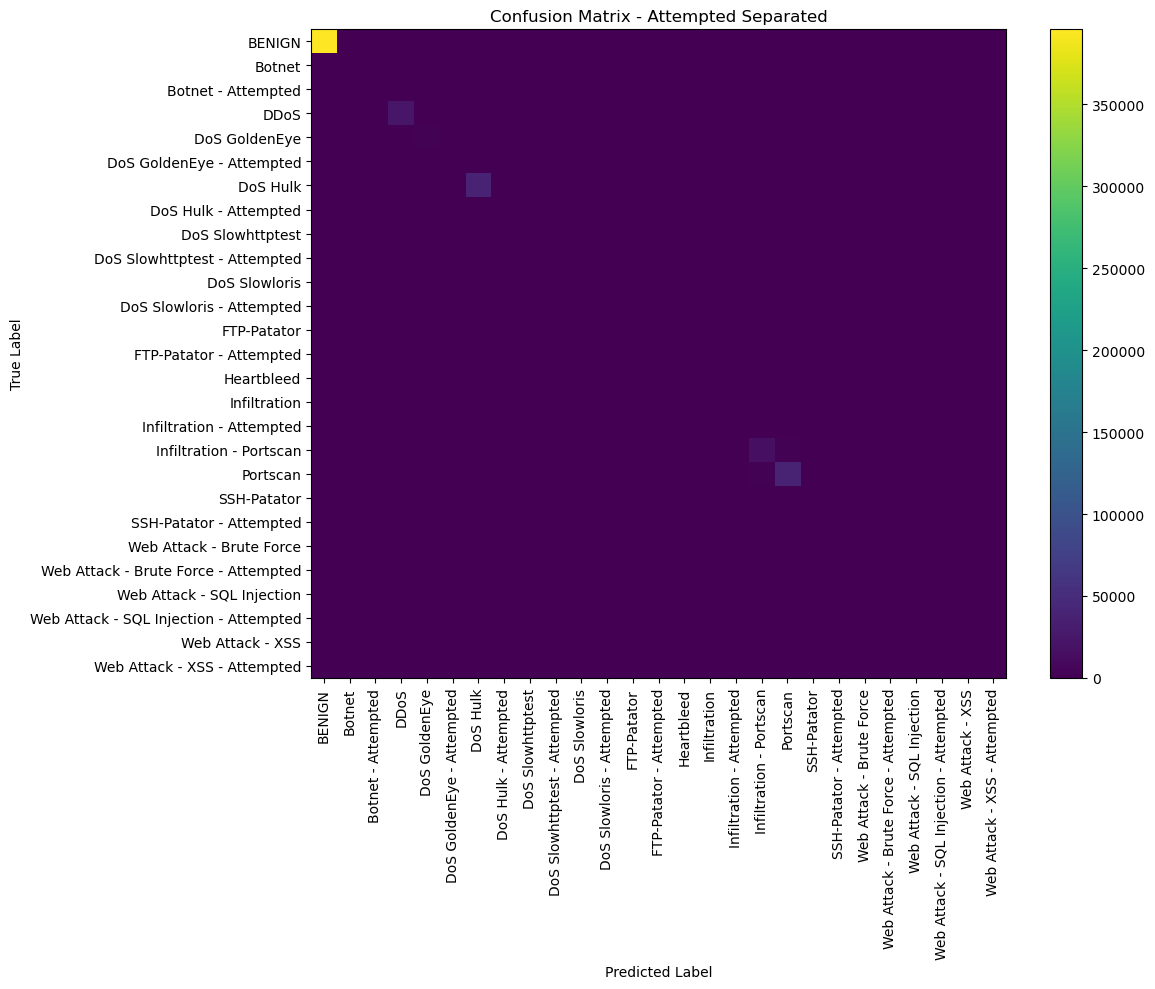

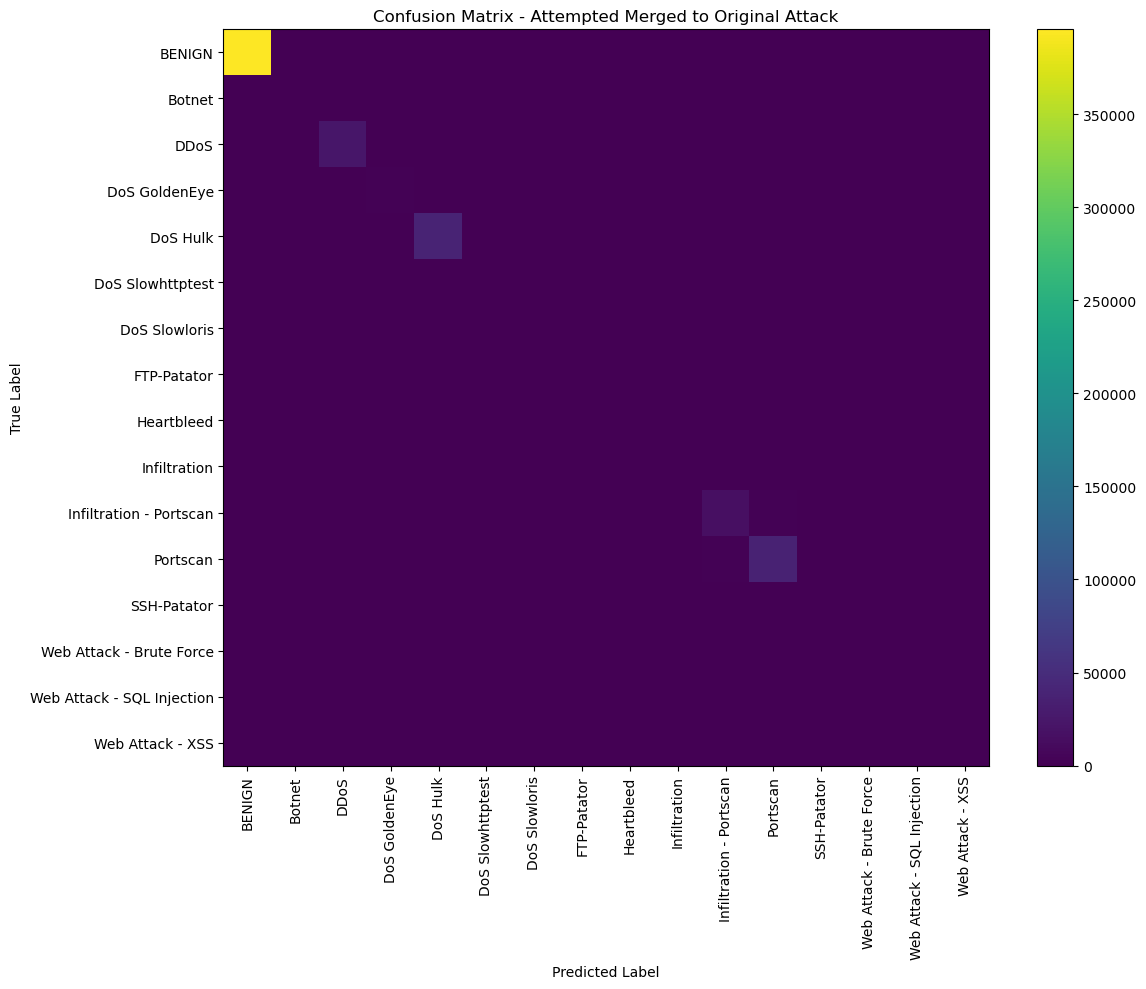

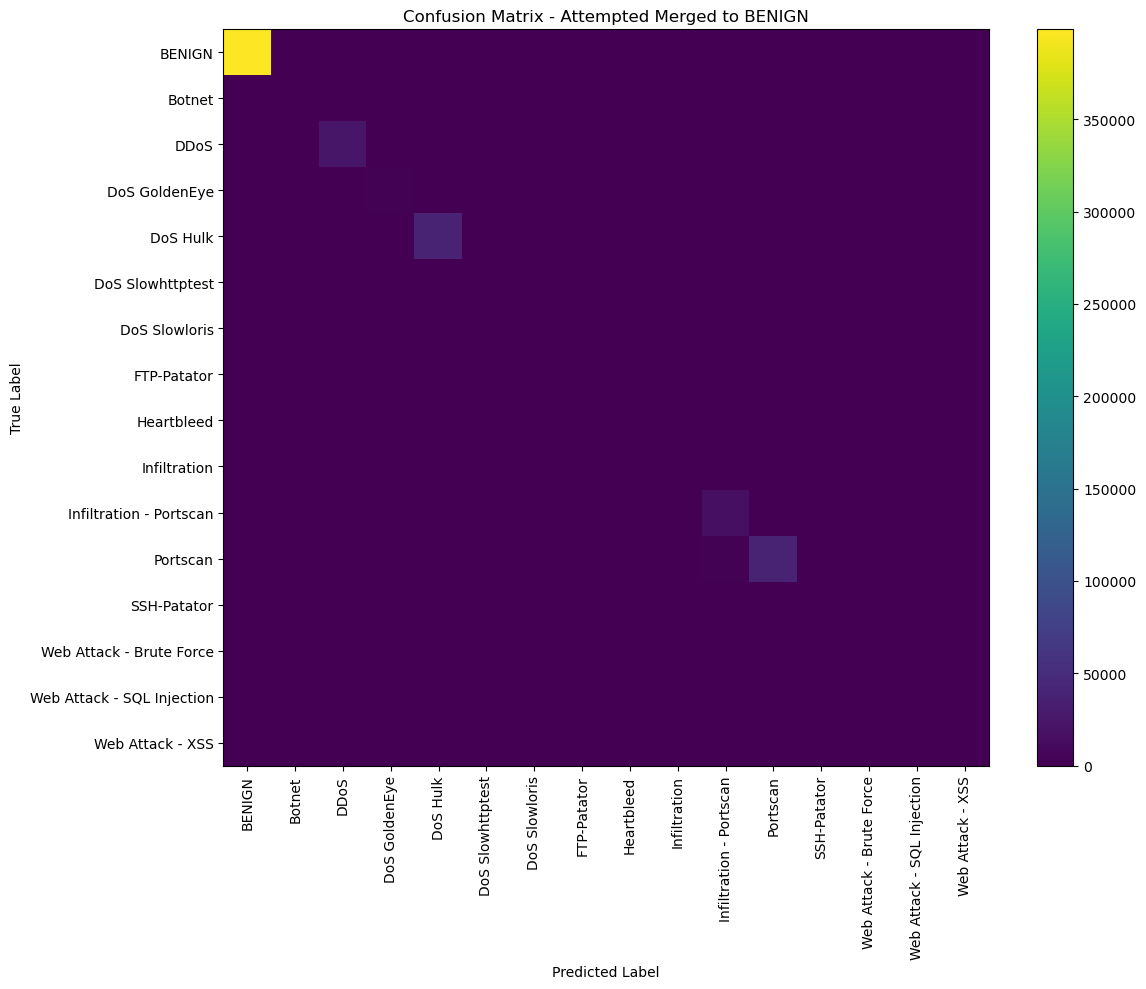

In [57]:
plot_confusion_matrix_heatmap(
    result_sep["confusion_matrix_df"],
    title="Confusion Matrix - Attempted Separated"
)

plot_confusion_matrix_heatmap(
    result_org["confusion_matrix_df"],
    title="Confusion Matrix - Attempted Merged to Original Attack"
)

plot_confusion_matrix_heatmap(
    result_ben["confusion_matrix_df"],
    title="Confusion Matrix - Attempted Merged to BENIGN"
)